## Lab 5

Step 0 - Import Libraries

In [5]:
# Import Required Libraries
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Perform image data extraction, then define the image locations. In this example, the image folder is located in the same directory as the Python file.

In [7]:
# Image directories
train_dir = "/content/drive/MyDrive/Machine Learning 2025/images/training"
test_dir = "/content/drive/MyDrive/Machine Learning 2025/images/test"

Step 1 - Load Data and Visualize

Create a function to compile a list of all image paths.

In [8]:
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = str(dir).split('/')[-1]
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))

    return img_list

Load training images

In [9]:
# Load training data
train_img = load_dataset(train_dir)

Check one of the entries in the list. The list should contain tuples with two elements, namely the image data and the image label.

In [10]:
# Check the first data
# It should be a tuple consist of arrays of image and image labels
train_img[0]

(array([[[142, 189, 233],
         [144, 191, 235],
         [144, 191, 235],
         ...,
         [150, 193, 236],
         [151, 194, 237],
         [151, 194, 237]],
 
        [[141, 188, 232],
         [144, 191, 235],
         [144, 191, 235],
         ...,
         [156, 199, 242],
         [156, 199, 242],
         [156, 199, 242]],
 
        [[141, 188, 232],
         [144, 191, 235],
         [144, 191, 235],
         ...,
         [153, 196, 239],
         [154, 197, 240],
         [154, 197, 240]],
 
        ...,
 
        [[100,  97,  90],
         [122, 119, 112],
         [126, 123, 114],
         ...,
         [ 83,  87,  98],
         [ 83,  87,  98],
         [ 83,  87,  98]],
 
        [[ 98,  93,  87],
         [124, 119, 113],
         [116, 112, 103],
         ...,
         [ 86,  90, 102],
         [ 85,  89, 101],
         [ 80,  84,  96]],
 
        [[ 99,  94,  88],
         [112, 107, 101],
         [107, 103,  94],
         ...,
         [ 86,  90, 102],
  

Check image size at random

In [11]:
# Random size checking
pick_random = np.random.randint(0, len(train_img))

# Check img size
print(f'Image {pick_random}')
print(train_img[pick_random][0].shape)

Image 200
(737, 1024, 3)


Display images for visual inspection. Create a function to assist in visualizing images

In [12]:
# Function to Visualize
def random_img_viz(img_list):
    rand_num = np.random.randint(0, len(img_list))

    img = img_list[rand_num][0]
    label = img_list[rand_num][1]
    label_str = 'day' if label == 1 else 'night'

    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')

Visualize an image at random

Shape	: (469, 640, 3)
Label	: night


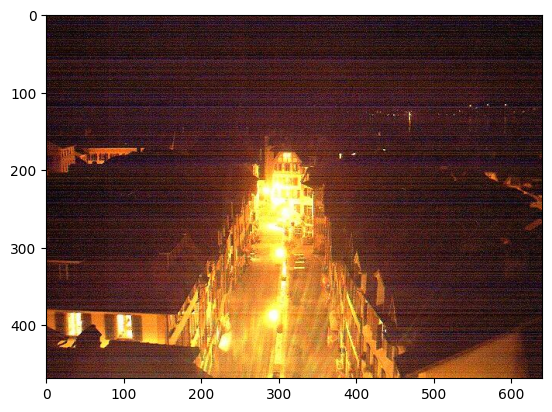

In [13]:
random_img_viz(train_img)

Step 3 - Data Preprocessing

At this stage, we will perform two primary processes, namely standardization of image size, and encoding of image labels.

Create the following function to standardize image size.

In [14]:
def standarized_input(image):
    # resize to w: 1100, h:600
    std_img = cv2.resize(image, (1100,600))

    return std_img

Next, create a function for label encoding requirements.

In [15]:
def label_encoder(label):
    # Encode the label
    # day as 1; night as 0
    num_val = 0

    if(label == 'day'):
        num_val = 1

    return num_val

Finally, create a function to perform both operations concurrently for all images in the list.

In [16]:
def preprocess(img_list):
    std_img_list = []

    for item in img_list:
        image = item[0]
        label = item[1]

        # Standarized the image
        std_img = standarized_input(image)

        # Create the label
        img_label = label_encoder(label)

        std_img_list.append((std_img, img_label))

    return std_img_list

Perform data preprocessing on the training data.

In [17]:
train_std_img_list = preprocess(train_img)

Perform random checks on image sizes.

In [18]:
# Random size checking
pick_random = np.random.randint(0, len(train_std_img_list))

# Check img size
print(f'Image {pick_random}')
print(train_std_img_list[pick_random][0].shape)

Image 11
(600, 1100, 3)


WARNING! Note the dimensions (shape) of the image data. The shape attribute will display in the context of rows (height) x columns (width)

Perform visual inspection with the previously defined random_img_viz function on the preprocessed images.

The result will appear as the following image,

Shape	: (600, 1100, 3)
Label	: 0


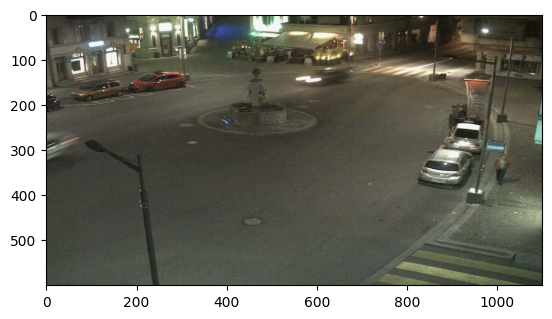

In [19]:
random_img_viz(train_std_img_list)

Step 4 - Feature Extraction

Create the following function to obtain the mean brightness value.

In [20]:
# Get feature based on average brightness using HSV colorspace
def avg_brightness(image):
    # Convert image to HSV
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Calculate the avg of brightness
    sum_brightness = np.sum(img_hsv[:,:,2]) # take the 3rb value which is the V channel
    area = image.shape[0] * image.shape[1]
    avg = sum_brightness / area

    return avg

Perform a check on a random image. REMEMBER! Use an image that has undergone preprocessing!

Image 212
Avg Brighness: 98.9818


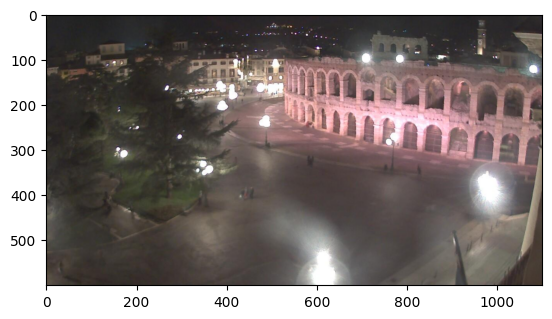

In [21]:
# Check on random image
rand_img = np.random.randint(0, len(train_std_img_list))

feature_img = train_std_img_list[rand_img][0]

avg_img = avg_brightness(feature_img)

print(f'Image {rand_img}')
print(f'Avg Brighness: {avg_img:.4f}')
plt.imshow(feature_img)

Step 5 - Classification using Threshold Method

At this stage, we will perform a simple classification process using a threshold value of the mean brightness that we define manually.

Create the following function,

In [22]:
def predict_label(img, threshold):
    # Computer average brightness
    avg = avg_brightness(img)
    pred = 0

    # Predict the label based on user defined threshold
    if avg > threshold:
        pred = 1

    return pred

Perform a random prediction check on the training data

Image 5
Actual label: 1
Predicted label: 1


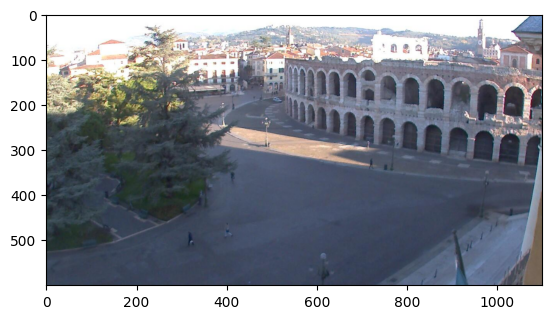

In [23]:
# Test the classifier on train data
rand_img = np.random.randint(0, len(train_std_img_list))

pred = predict_label(train_std_img_list[rand_img][0], threshold=120)

# Evaluate
print(f'Image {rand_img}')
print(f'Actual label: {train_std_img_list[rand_img][1]}')
print(f'Predicted label: {pred}')
plt.imshow(train_std_img_list[rand_img][0])

Step 6 - Manual Evaluation

Next we will create a simple model evaluation function, namely by comparing correctly predicted labels across the dataset. Recall the concept of the confusion matrix.

Create the following function,

In [24]:
def evaluate(img_list, threshold):
    miss_labels = []

    for file in img_list:
        # Get the ground truth / correct label
        img = file[0]
        label = file[1]

        # Get prediction
        pred_label = predict_label(img, threshold)

        # Compare ground truth and pred
        if pred_label != label:
            miss_labels.append((img, pred_label, label))

    total_img = len(img_list)
    corr_pred = total_img - len(miss_labels)
    accuracy = corr_pred / total_img

    print(f'Accuracy: {accuracy:.4f}')

Evaluate the training data using a threshold value of 120.

In [25]:
# Evaluate on train data
evaluate(train_std_img_list, threshold=120)

Accuracy: 0.8417


## Classification with SVM

Alternative Step 4 - Constructing Feature Vectors.

The fundamental difference from the previous step 4 is that we will tabulate all mean brightness values across the dataset and store them in a table. In this context, we will create a table with feature and label columns.

Create the following function,

In [26]:
# Create function to extract feature for every images and stored in tabular data
# Stored in Pandas dataframe
def extract_avg_bright_feature(img_list):
    avg_list = []
    labels = []

    for img in img_list:
        img_avg = avg_brightness(img[0]) # Get the avg brightness from image
        img_label = img[1] # Get the image label

        avg_list.append(img_avg)
        labels.append(img_label)

    # Stack data in columcular way
    data = np.column_stack((avg_list, labels))
    # Create a Pandas dataframe
    df = pd.DataFrame(data, columns=['AVG_BRIGHT', 'LABELS'])

    return df

Check the results on the training data,

In [32]:
# Extract feature on train data
train_avg_img = extract_avg_bright_feature(train_std_img_list)
print(f'Shape: {train_avg_img.shape}')
train_avg_img.head(10)

Shape: (240, 2)


,AVG_BRIGHT,LABELS
0,200.020276,1.0
1,137.345858,1.0
2,129.001000,1.0
3,103.368729,1.0
4,141.002721,1.0
5,129.237782,1.0
6,143.662879,1.0
7,118.636964,1.0
8,112.258486,1.0
9,107.650714,1.0


Perform the same procedure on the test data

In [33]:
# Do the same thing on test data
test_avg_img = extract_avg_bright_feature(test_std_img_list)
print(f'Shape: {test_avg_img.shape}')
test_avg_img.head(150)

Shape: (160, 2)


,AVG_BRIGHT,LABELS
0,151.462197,1.0
1,105.529983,1.0
2,144.243461,1.0
3,134.486027,1.0
4,168.672429,1.0
...,...,...
145,19.274156,0.0
146,18.619045,0.0
147,87.100448,0.0
148,94.264071,0.0


Step 5 - Build SVM Model

Next, we will create an SVM model with an RBF kernel (default) using the scikit-learn library.

In [34]:
# import requied library
from sklearn.svm import SVC

# Split data and label
X_train = train_avg_img.iloc[:,0].values.reshape(-1,1)
y_train = train_avg_img.iloc[:,1]
X_test = test_avg_img.iloc[:,0].values.reshape(-1,1)
y_test = test_avg_img.iloc[:,1]

model = SVC()
model.fit(X_train, y_train)

SVC()

Step 6 - Evaluation

Subsequently, we will perform evaluation on the training and testing data using the scikit-learn library.

In [35]:
from sklearn.metrics import accuracy_score

# Make a prediction on train data
y_train_pred = model.predict(X_train)

# Get the accuracy on train data
acc_train = accuracy_score(y_train, y_train_pred)

# Make a prediction on test data
y_test_pred = model.predict(X_test)

# Get the accuracy on test data
acc_test = accuracy_score(y_test, y_test_pred)

# Print Eval Result
print(f'Accuracy on train: {acc_train}')
print(f'Accuracy on test: {acc_test}')

Accuracy on train: 0.8583333333333333
Accuracy on test: 0.9
